# PointNeXt Multi-Object Point Cloud Segmentation + Per-Class Volume Estimation

**Pipeline overview**

1. **Task 1** — Dataset split (Train / Validation / Test), PointNeXt multi-class segmentation
   (`0 = Environment/Others`, `1 = Wood Powder`), test-phase visualization
   (**Green = Wood Powder, Red = Others**).
2. **Volume Estimation** — Geometric features from segmented wood-powder points →
   best regression model (Linear / Ridge / RandomForest / GradientBoosting, selected by
   cross-validated MAE) + optional **DGCNN-Regression** head. Error analysis vs Ground-Truth
   volume file (MAE, RMSE, MAPE, R²).
3. **Task 2** — Standalone inference pipeline: load best checkpoint → run on one or many
   point clouds → visualize segmentation → output estimated volume.

**Expected data layout**

```
data/
 ├── pointclouds/            # 20,000 files: .npy (N,4) or .txt/.xyz/.pts  ->  x y z label
 └── gt_volumes.csv          # columns: filename,volume   (filename without extension is also OK)
```

Each point cloud file must contain per-point rows `x y z label` (label ∈ {0,1}).
Adjust `CONFIG` below to match your paths, units and hardware.


## 0. Setup & Configuration

In [1]:
# ============================== IMPORTS ==============================
# pip install torch numpy pandas scikit-learn scipy matplotlib joblib tqdm laspy plyfile plotly
# pip install open3d   (optional, for interactive 3D visualization; matplotlib fallback included)

import os, sys, glob, json, random, time, math, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.spatial import ConvexHull
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import joblib
from tqdm.auto import tqdm
import mlflow
import datetime
try:
    import open3d as o3d
    HAS_OPEN3D = True
except Exception:
    HAS_OPEN3D = False
    print("[INFO] open3d not found -> matplotlib will be used for visualization.")

try:
    import laspy
    HAS_LASPY = True
except Exception:
    HAS_LASPY = False
    print("[INFO] laspy not found -> .las/.laz files cannot be read. "
          "Install with: pip install laspy")

try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False
    print("[INFO] plotly not found -> interactive in-notebook 3D disabled "
          "(matplotlib 3D fallback). Install with: pip install plotly")

try:
    from plyfile import PlyData
    HAS_PLYFILE = True
except Exception:
    HAS_PLYFILE = False   # .ply labels need plyfile; geometry-only fallback via open3d
    print("[INFO] plyfile not found -> .ply label fields cannot be read "
          "(geometry-only via open3d). Install with: pip install plyfile")

warnings.filterwarnings("ignore")
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
PyTorch: 2.8.0+cu126 | CUDA available: True


In [2]:
mlflow.set_tracking_uri("http://localhost:5000/")
mlflow.set_experiment("PointNeXt")

<Experiment: artifact_location='mlflow-artifacts:/5', creation_time=1783127030426, effective_trace_archival_retention=None, experiment_id='5', last_update_time=1783127030426, lifecycle_stage='active', name='PointNeXt', tags={}, trace_location=None, workspace='default'>

In [3]:
# ============================== CONFIG ==============================
CONFIG = {
    # ---- Paths ----
    "data_dir":        "data/train",          # folder with 20,000 point cloud files
    "gt_volume_csv":   "data/gt_volume.csv", # CSV: filename,volume
    "checkpoint_dir":  "checkpoints",
    "results_dir":     "data/results",
    "splits_file":     "checkpoints/splits.json",  # REQUIRED: used by make_or_load_splits()

    # ---- Data ----
    "file_exts":       [".las", ".laz", ".npy", ".npz", ".ply", ".pcd",
                        ".txt", ".xyz", ".pts", ".csv", ".asc"],
    "num_points":      4096,      # points sampled per training example (chunk size)
    "train_ratio":     0.70,
    "val_ratio":       0.15,      # test = 1 - train - val = 0.15
    "seed":            42,

    # ---- PointNeXt-S (SA downsampling + InvResMLP residual blocks) ----
    "sa_npoints":      [1024, 256, 64, 16],   # FPS points per encoder stage
    "sa_radii":        [0.1, 0.2, 0.4, 0.8],  # ball-query radii (normalized units)
    "sa_nsamples":     [32, 32, 32, 32],
    "nx_blocks":       [1, 1, 1, 1],          # InvResMLP blocks appended per stage
    "nx_expansion":    4,                     # MLP expansion inside InvResMLP
    "dropout":         0.5,

    # ---- Multi-class labels: 0 = environment, 1..K = target objects ----
    "num_classes":     4,          # 1 + K  -> set to YOUR total number of classes
    "class_names":     {0: "Environment", 1: "WoodPowder", 2: "Object2", 3: "Object3"},
    "gt_class":        1,          # GT volumes exist ONLY for this class (data/gt_volume.csv)
    # True  -> apply the class-1-trained ML regressor to the OTHER target classes too
    #          (their predictions are flagged "uncalibrated": no GT to validate them)
    # False -> other classes get geometry-based volume only (recommended for now)
    "apply_regressor_to_all_classes": False,

    # ---- Training ----
    "batch_size":      8,
    "epochs":          10,
    "lr":              1e-3,
    "weight_decay":    1e-4,
    "num_workers":     0,       # 0 = safest in Jupyter; raise to 2 after verifying (uses spawn)
    "use_class_weights": True,    # handle class imbalance
    "chunks_per_cloud_train": 4,  # how many random 4096-chunks per cloud per epoch

    # ---- Inference over full clouds (400k–800k points) ----
    "infer_chunk_batch": 16,      # chunks per forward pass

    # ---- Volume features ----
    # voxel sizes MUST match your coordinate units (e.g. meters). Adjust!
    "voxel_sizes":     [0.01, 0.02, 0.05],

    # ---- Visualization ----
    "max_vis_points":  120000,    # subsample for matplotlib rendering speed
    "n_test_visualize": 5,        # how many test clouds to visualize during Task 1
}

# ---- Resource / fallback settings ----
CONFIG.setdefault("min_free_vram_gb", 2.0)     # free VRAM below this -> CPU + RAM fallback
CONFIG.setdefault("cpu_batch_size", 2)         # batch size used when training on CPU
CONFIG.setdefault("cpu_infer_chunk_batch", 4)  # inference chunk batch on CPU

os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
os.makedirs(CONFIG["results_dir"], exist_ok=True)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

# ============== TOTAL DATASET SIZE SCAN ==============
def scan_dataset_size(cfg):
    """Compute total on-disk dataset size + estimated peak RAM for CPU training.
    Training streams ONE cloud at a time per worker, so peak RAM is governed by the
    largest cloud x (num_workers + 1), NOT by the whole dataset."""
    files = []
    for e in cfg["file_exts"]:
        files += glob.glob(os.path.join(cfg["data_dir"], "*" + e))
    if not files:
        print(f"[DATASET] No files found in {cfg['data_dir']} (scan skipped).")
        return None
    sizes = np.array([os.path.getsize(f) for f in files], dtype=np.float64)
    total_gb, avg_mb, max_mb = sizes.sum() / 1024**3, sizes.mean() / 1024**2, sizes.max() / 1024**2
    # rough peak-RAM estimate: (workers+1) clouds resident, ~3x overhead for
    # float64 parsing / label arrays / normalization copies
    est_peak_gb = (cfg["num_workers"] + 1) * (max_mb / 1024) * 3.0
    print(f"[DATASET] files: {len(files):,} | total size: {total_gb:.2f} GB "
          f"| avg file: {avg_mb:.1f} MB | largest file: {max_mb:.1f} MB")
    print(f"[DATASET] estimated peak RAM while training (streaming): ~{est_peak_gb:.1f} GB "
          f"(num_workers={cfg['num_workers']})")
    return {"n_files": len(files), "total_gb": total_gb,
            "avg_mb": avg_mb, "max_mb": max_mb, "est_peak_ram_gb": est_peak_gb}

DATASET_STATS = scan_dataset_size(CONFIG)

# ============== DEVICE SELECTION: CUDA -> CPU + RAM FALLBACK ==============
def apply_cpu_settings(cfg):
    """Tune CONFIG for CPU + RAM training."""
    cfg["batch_size"] = min(cfg["batch_size"], cfg["cpu_batch_size"])
    cfg["infer_chunk_batch"] = min(cfg["infer_chunk_batch"], cfg["cpu_infer_chunk_batch"])
    cfg["num_workers"] = 0                       # avoid RAM duplication across workers
    n_threads = max(1, (os.cpu_count() or 2) - 1)
    torch.set_num_threads(n_threads)
    print(f"[DEVICE] CPU mode: batch_size={cfg['batch_size']}, "
          f"infer_chunk_batch={cfg['infer_chunk_batch']}, torch threads={n_threads}")

def select_device(cfg):
    """CUDA only if available AND enough free VRAM; otherwise CPU + RAM."""
    if not torch.cuda.is_available():
        print("[DEVICE] CUDA not available -> full training/testing on CPU + RAM.")
        apply_cpu_settings(cfg)
        return torch.device("cpu")
    try:
        free_b, total_b = torch.cuda.mem_get_info()
        free_gb, total_gb = free_b / 1024**3, total_b / 1024**3
    except Exception:
        free_gb = total_gb = None
    if free_gb is not None and free_gb < cfg["min_free_vram_gb"]:
        print(f"[DEVICE] Only {free_gb:.2f} GB free VRAM "
              f"(< {cfg['min_free_vram_gb']} GB required) -> CPU + RAM fallback.")
        apply_cpu_settings(cfg)
        return torch.device("cpu")
    if free_gb is not None:
        print(f"[DEVICE] Using CUDA: {torch.cuda.get_device_name(0)} "
              f"| free VRAM {free_gb:.2f}/{total_gb:.2f} GB")
    else:
        print(f"[DEVICE] Using CUDA: {torch.cuda.get_device_name(0)}")
    return torch.device("cuda")

DEVICE = select_device(CONFIG)
print("Device:", DEVICE)

[DATASET] files: 45 | total size: 0.59 GB | avg file: 13.3 MB | largest file: 23.3 MB
[DATASET] estimated peak RAM while training (streaming): ~0.1 GB (num_workers=0)
[DEVICE] Using CUDA: NVIDIA GeForce RTX 3060 | free VRAM 11.51/11.63 GB
Device: cuda


## 1. Data Loading, Normalization & Train/Val/Test Split (Task 1)

- File-level split → **70% train / 15% val / 15% test** (saved to `splits.json` for reproducibility).
- Each cloud is normalized (centered + scaled to unit sphere) **once for the whole cloud**;
  the normalization parameters are kept so original coordinates can be recovered for volume computation.


In [4]:
# ============================== FILE I/O ==============================
def list_pointcloud_files(data_dir, exts):
    files = []
    for e in exts:
        files += glob.glob(os.path.join(data_dir, "*" + e))
    return sorted(files)

# Per-point label field names searched inside .las/.ply/.pcd files, in priority order:
LABEL_KEYS = ("label", "labels", "classification", "class",
              "scalar_label", "scalar_classification", "seg", "pred")

def _sanitize_labels(lbl):
    """Multi-class labels 0..K: 0 = environment, 1..K = target objects.
    Any out-of-range code is mapped to 0 (environment).
    >>> If your files use different codes, remap here. <<<"""
    if lbl is None:
        return None
    lbl = np.asarray(lbl).astype(np.int64)
    K = CONFIG["num_classes"]
    bad = (lbl < 0) | (lbl >= K)
    if bad.any():
        lbl = lbl.copy()
        lbl[bad] = 0
    return lbl

def _load_las(path):
    """.las/.laz via laspy. Label priority: extra dim 'label' -> 'classification'."""
    assert HAS_LASPY, "laspy is required for .las/.laz files: pip install laspy"
    las = laspy.read(path)
    pts = np.vstack([np.asarray(las.x), np.asarray(las.y), np.asarray(las.z)]).T
    pts = pts.astype(np.float64)
    lbl, dim_names = None, set(las.point_format.dimension_names)
    for key in LABEL_KEYS:
        if key in dim_names:
            lbl = np.asarray(las[key], dtype=np.int64)
            break
    return pts, _sanitize_labels(lbl)

def _load_ply(path):
    """.ply: plyfile reads custom per-vertex label properties; open3d fallback = geometry only."""
    if HAS_PLYFILE:
        v = PlyData.read(path)["vertex"]
        pts = np.vstack([np.asarray(v["x"]), np.asarray(v["y"]),
                         np.asarray(v["z"])]).T.astype(np.float32)
        names = v.data.dtype.names or ()
        lbl = None
        for key in LABEL_KEYS:
            if key in names:
                lbl = np.asarray(v[key])
                break
        return pts, _sanitize_labels(lbl)
    if HAS_OPEN3D:
        pcd = o3d.io.read_point_cloud(path)
        return np.asarray(pcd.points, dtype=np.float32), None
    raise RuntimeError("Reading .ply requires plyfile or open3d: pip install plyfile")

def _load_pcd(path):
    """.pcd via open3d (tensor API reads custom attributes like 'label' when present)."""
    assert HAS_OPEN3D, "open3d is required for .pcd files: pip install open3d"
    lbl = None
    try:
        tp = o3d.t.io.read_point_cloud(path)
        pts = tp.point["positions"].numpy().astype(np.float32)
        for key in LABEL_KEYS:
            if key in tp.point:
                lbl = tp.point[key].numpy().reshape(-1)
                break
    except Exception:
        pcd = o3d.io.read_point_cloud(path)
        pts = np.asarray(pcd.points, dtype=np.float32)
    return pts, _sanitize_labels(lbl)

def _load_text(path):
    """Whitespace / comma separated text (.txt/.xyz/.pts/.csv/.asc), optional header row."""
    for kwargs in (dict(), dict(delimiter=","), dict(skiprows=1), dict(delimiter=",", skiprows=1)):
        try:
            return np.loadtxt(path, **kwargs)
        except ValueError:
            continue
    return np.genfromtxt(path, delimiter=",", skip_header=1)

def load_pointcloud(path):
    """Universal point cloud loader.
    Supported: .las .laz .npy .npz .ply .pcd .txt .xyz .pts .csv .asc
    Returns (points[N,3] float32, labels[N] int64 or None)."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".las", ".laz"):
        return _load_las(path)
    if ext == ".ply":
        return _load_ply(path)
    if ext == ".pcd":
        return _load_pcd(path)
    if ext == ".npy":
        arr = np.load(path)
    elif ext == ".npz":
        z = np.load(path)
        for key in ("points", "data", "arr_0"):
            if key in z:
                arr = z[key]
                break
        else:
            arr = z[list(z.keys())[0]]
    else:  # text formats
        arr = _load_text(path)

    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim != 2 or arr.shape[1] < 3:
        raise ValueError(f"Bad point cloud shape {arr.shape} in {path}")
    pts = arr[:, :3].astype(np.float32)
    lbl = _sanitize_labels(arr[:, 3]) if arr.shape[1] >= 4 else None
    return pts, lbl

def normalize_cloud(points):
    """Center to origin and scale to unit sphere. Returns normalized pts, centroid, scale."""
    centroid = points.mean(axis=0)
    pts = points - centroid
    scale = np.max(np.linalg.norm(pts, axis=1))
    scale = scale if scale > 0 else 1.0
    return (pts / scale).astype(np.float32), centroid, float(scale)

# ============================== SPLIT ==============================
def make_or_load_splits(cfg):
    if os.path.exists(cfg["splits_file"]):
        with open(cfg["splits_file"]) as f:
            splits = json.load(f)
        print("Loaded existing splits:",
              {k: len(v) for k, v in splits.items()})
        return splits
    files = list_pointcloud_files(cfg["data_dir"], cfg["file_exts"])
    assert len(files) > 0, f"No point cloud files found in {cfg['data_dir']}"
    rng = np.random.RandomState(cfg["seed"])
    idx = rng.permutation(len(files))
    n_tr = int(len(files) * cfg["train_ratio"])
    n_va = int(len(files) * cfg["val_ratio"])
    splits = {
        "train": [files[i] for i in idx[:n_tr]],
        "val":   [files[i] for i in idx[n_tr:n_tr + n_va]],
        "test":  [files[i] for i in idx[n_tr + n_va:]],
    }
    with open(cfg["splits_file"], "w") as f:
        json.dump(splits, f, indent=2)
    print("Created splits:", {k: len(v) for k, v in splits.items()})
    return splits

splits = make_or_load_splits(CONFIG)

Loaded existing splits: {'train': 31, 'val': 6, 'test': 8}


### 1.1 (Recommended, one-time) Convert `.las`/`.txt` files to float32 `.npy`

Loading raw `.las`/`.txt` files with 400k–800k points inside the DataLoader is slow and
memory-heavy (a common cause of worker crashes / OOM kills). Run this cell **once** to
convert everything to compact float32 `.npy` (N×4: x y z label), then point
`CONFIG["data_dir"]` at the new folder. Loading becomes 10–50× faster and uses ~half the RAM.


In [5]:
# ============================== ONE-TIME .NPY CONVERSION (OPTIONAL) ==============================
RUN_CONVERSION = False              # set True, run once, then set back to False
NPY_DIR = "data/train_npy"

if RUN_CONVERSION:
    os.makedirs(NPY_DIR, exist_ok=True)
    src_files = list_pointcloud_files(CONFIG["data_dir"], CONFIG["file_exts"])
    for f in tqdm(src_files, desc="Converting to .npy"):
        name = os.path.splitext(os.path.basename(f))[0]
        out = os.path.join(NPY_DIR, name + ".npy")
        if os.path.exists(out):
            continue
        pts, lbl = load_pointcloud(f)
        assert lbl is not None, f"Labels missing in {f}"
        np.save(out, np.hstack([pts, lbl[:, None].astype(np.float32)]).astype(np.float32))
    print(f"Done -> {NPY_DIR}")
    print("Ekhon korun:")
    print('  1) CONFIG["data_dir"] = "data/train_npy"  ebong CONFIG["file_exts"] = [".npy"]')
    print('  2) Purono split muchhe felun:  os.remove(CONFIG["splits_file"])')
    print("  3) Notebook-ti CONFIG cell theke abar chalan (splits notun path-e toiri hobe).")
else:
    print("Conversion skipped (RUN_CONVERSION = False).")

Conversion skipped (RUN_CONVERSION = False).


In [6]:
# ============================== DATASET ==============================
class MultiObjectDataset(Dataset):
    """
    Training/validation dataset.
    Each __getitem__ returns one random chunk of `num_points` points
    from a (whole-cloud-normalized) point cloud, plus per-point labels.
    `chunks_per_cloud` virtually enlarges the dataset so several chunks
    of each cloud are seen per epoch.
    """
    def __init__(self, files, num_points, chunks_per_cloud=1, augment=False):
        self.files = files
        self.num_points = num_points
        self.chunks_per_cloud = max(1, chunks_per_cloud)
        self.augment = augment

    def __len__(self):
        return len(self.files) * self.chunks_per_cloud

    def _augment(self, pts):
        # random rotation around z + jitter + small anisotropic scale
        theta = np.random.uniform(0, 2 * np.pi)
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
        pts = pts @ R.T
        pts *= np.random.uniform(0.9, 1.1, size=(1, 3)).astype(np.float32)
        pts += np.clip(0.005 * np.random.randn(*pts.shape), -0.02, 0.02).astype(np.float32)
        return pts

    def __getitem__(self, idx):
        path = self.files[idx % len(self.files)]
        pts, lbl = load_pointcloud(path)
        assert lbl is not None, f"Labels missing in {path}"
        pts, _, _ = normalize_cloud(pts)

        n = pts.shape[0]
        if n >= self.num_points:
            choice = np.random.choice(n, self.num_points, replace=False)
        else:
            choice = np.random.choice(n, self.num_points, replace=True)
        pts, lbl = pts[choice], lbl[choice]

        if self.augment:
            pts = self._augment(pts)

        # PointNeXt expects (3, N)
        return torch.from_numpy(pts.T.copy()), torch.from_numpy(lbl.copy())

train_ds = MultiObjectDataset(splits["train"], CONFIG["num_points"],
                             chunks_per_cloud=CONFIG["chunks_per_cloud_train"], augment=True)
val_ds   = MultiObjectDataset(splits["val"], CONFIG["num_points"], chunks_per_cloud=1, augment=False)

# ----- DataLoader: safe worker configuration -----
# Jupyter-e num_workers>0 + default fork start method praayoi worker crash kore
# (Bad file descriptor / semaphore errors) — bishesh kore RAM shesh hole (OOM kill).
# Tai: (1) prothome num_workers=0 diye verify korun, (2) tarpor CONFIG["num_workers"]=2
# korle spawn context + persistent workers babohar hobe.

def build_loaders():
    """(Re)build DataLoaders from CURRENT CONFIG values -- batch_size / num_workers
    may be auto-reduced later by the GPU smoke test or the CPU + RAM fallback."""
    kw = dict(batch_size=CONFIG["batch_size"],
              pin_memory=(DEVICE.type == "cuda"))
    if CONFIG["num_workers"] > 0:
        kw.update(num_workers=CONFIG["num_workers"], persistent_workers=True,
                  prefetch_factor=2, multiprocessing_context="spawn")
    else:
        kw.update(num_workers=0)
    tr = DataLoader(train_ds, shuffle=True, drop_last=True, **kw)
    va = DataLoader(val_ds, shuffle=False, **kw)
    print(f"[LOADERS] batch_size={CONFIG['batch_size']} "
          f"num_workers={CONFIG['num_workers']} device={DEVICE}")
    return tr, va

train_loader, val_loader = build_loaders()
print(f"Train chunks/epoch: {len(train_ds)} | Val chunks: {len(val_ds)}")

[LOADERS] batch_size=8 num_workers=0 device=cuda
Train chunks/epoch: 124 | Val chunks: 6


In [7]:
# ============================== CLASS WEIGHTS ==============================
def estimate_class_weights(files, n_sample_files=200, num_classes=2, seed=42):
    """Estimate inverse-frequency class weights from a random subset of training files."""
    rng = np.random.RandomState(seed)
    sel = rng.choice(len(files), size=min(n_sample_files, len(files)), replace=False)
    counts = np.zeros(num_classes, dtype=np.float64)
    for i in tqdm(sel, desc="Estimating class weights"):
        _, lbl = load_pointcloud(files[i])
        binc = np.bincount(lbl, minlength=num_classes)
        counts += binc[:num_classes]
    freq = counts / counts.sum()
    w = 1.0 / np.clip(freq, 1e-6, None)
    w = w / w.sum() * num_classes
    print("Class frequencies:", freq, "-> weights:", w)
    return torch.tensor(w, dtype=torch.float32)

if CONFIG["use_class_weights"]:
    class_weights = estimate_class_weights(splits["train"],
                                           num_classes=CONFIG["num_classes"],
                                           seed=CONFIG["seed"]).to(DEVICE)
else:
    class_weights = None

Estimating class weights:   0%|          | 0/31 [00:00<?, ?it/s]

Class frequencies: [0.39165313 0.60834687 0.         0.        ] -> weights: [5.10654873e-06 3.28759119e-06 1.99999580e+00 1.99999580e+00]


## 2. PointNeXt-S Multi-Class Segmentation Model

PointNeXt (Qian et al., NeurIPS 2022) modernizes the PointNet++ backbone: each
set-abstraction (FPS + ball query + shared MLP + max-pool) stage is followed by
residual **InvResMLP** blocks (local aggregation + inverted-bottleneck MLP). The
decoder is the classic 3-NN feature propagation with skip connections. Pure
PyTorch — no compiled CUDA extensions required, so it runs anywhere PyTorch runs.
Interface: `model(x)` with `x (B,3,N)` → logits `(B,num_classes,N)`;
`model(x, return_embedding=True)` → global feature for the regression variant.

In [8]:
# ============================== POINTNEXT-S ==============================
# PointNeXt = PointNet++ backbone modernized with residual InvResMLP blocks
# (Qian et al., NeurIPS 2022). Encoder: SA (FPS + ball query + MLP + maxpool)
# downsampling followed by InvResMLP residual blocks per stage; decoder: the
# classic feature-propagation (3-NN interpolation + skip). Pure PyTorch.
def square_distance(src, dst):
    """src: (B,N,3), dst: (B,M,3) -> (B,N,M) squared euclidean distances."""
    return torch.cdist(src, dst, p=2.0) ** 2

def index_points(points, idx):
    """points: (B,N,C); idx: (B,S) or (B,S,K) -> gathered points."""
    B = points.shape[0]
    view_shape = [B] + [1] * (idx.dim() - 1)
    repeat_shape = list(idx.shape); repeat_shape[0] = 1
    batch_idx = torch.arange(B, device=points.device).view(view_shape).repeat(repeat_shape)
    return points[batch_idx, idx, :]

def farthest_point_sample(xyz, npoint):
    """xyz: (B,N,3) -> (B,npoint) indices of FPS-selected points."""
    B, N, _ = xyz.shape
    device = xyz.device
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    distance = torch.full((B, N), 1e10, device=device)
    farthest = torch.randint(0, N, (B,), dtype=torch.long, device=device)
    batch_idx = torch.arange(B, dtype=torch.long, device=device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_idx, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, dim=-1)
        distance = torch.minimum(distance, dist)
        farthest = torch.max(distance, dim=-1)[1]
    return centroids

def query_ball_point(radius, nsample, xyz, new_xyz):
    """Group up to nsample neighbours within radius around each new_xyz centroid.
    xyz: (B,N,3), new_xyz: (B,S,3) -> (B,S,nsample) indices."""
    B, N, _ = xyz.shape
    nsample = min(nsample, N)
    S = new_xyz.shape[1]
    device = xyz.device
    group_idx = torch.arange(N, device=device).view(1, 1, N).repeat(B, S, 1)
    sqrdists = square_distance(new_xyz, xyz)                     # (B,S,N)
    group_idx[sqrdists > radius ** 2] = N                        # mark out-of-radius
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]        # keep closest-index nsample
    group_first = group_idx[:, :, 0:1].repeat(1, 1, nsample)     # fallback = first in-ball point
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx


class PointNetSetAbstraction(nn.Module):
    """FPS -> ball query -> shared MLP -> max pool."""
    def __init__(self, npoint, radius, nsample, in_channel, mlp, group_all=False):
        super().__init__()
        self.npoint, self.radius, self.nsample, self.group_all = npoint, radius, nsample, group_all
        self.convs, self.bns = nn.ModuleList(), nn.ModuleList()
        last = in_channel
        for out in mlp:
            self.convs.append(nn.Conv2d(last, out, 1))
            self.bns.append(nn.BatchNorm2d(out))
            last = out

    def forward(self, xyz, points):
        """xyz: (B,3,N); points: (B,C,N) or None -> new_xyz (B,3,S), new_points (B,mlp[-1],S)."""
        xyz_t = xyz.permute(0, 2, 1)                             # (B,N,3)
        points_t = points.permute(0, 2, 1) if points is not None else None

        if self.group_all:
            new_xyz_t = torch.zeros(xyz_t.shape[0], 1, 3, device=xyz.device)
            grouped_xyz = xyz_t.unsqueeze(1)                     # (B,1,N,3)
            grouped = torch.cat([grouped_xyz, points_t.unsqueeze(1)], dim=-1) \
                      if points_t is not None else grouped_xyz
        else:
            fps_idx = farthest_point_sample(xyz_t, self.npoint)  # (B,S)
            new_xyz_t = index_points(xyz_t, fps_idx)             # (B,S,3)
            idx = query_ball_point(self.radius, self.nsample, xyz_t, new_xyz_t)
            grouped_xyz = index_points(xyz_t, idx) - new_xyz_t.unsqueeze(2)   # relative coords
            grouped = torch.cat([grouped_xyz, index_points(points_t, idx)], dim=-1) \
                      if points_t is not None else grouped_xyz   # (B,S,K,3+C)

        new_points = grouped.permute(0, 3, 2, 1)                 # (B,3+C,K,S)
        for conv, bn in zip(self.convs, self.bns):
            new_points = F.relu(bn(conv(new_points)))
        new_points = new_points.max(dim=2)[0]                    # (B,mlp[-1],S)
        return new_xyz_t.permute(0, 2, 1), new_points


class PointNetFeaturePropagation(nn.Module):
    """Inverse-distance-weighted 3-NN interpolation + skip connection + shared MLP."""
    def __init__(self, in_channel, mlp):
        super().__init__()
        self.convs, self.bns = nn.ModuleList(), nn.ModuleList()
        last = in_channel
        for out in mlp:
            self.convs.append(nn.Conv1d(last, out, 1))
            self.bns.append(nn.BatchNorm1d(out))
            last = out

    def forward(self, xyz1, xyz2, points1, points2):
        """xyz1: (B,3,N) dense targets; xyz2: (B,3,S) sparse sources;
        points1: (B,C1,N) skip features or None; points2: (B,C2,S)."""
        xyz1_t, xyz2_t = xyz1.permute(0, 2, 1), xyz2.permute(0, 2, 1)
        points2_t = points2.permute(0, 2, 1)                     # (B,S,C2)

        if xyz2_t.shape[1] == 1:
            interpolated = points2_t.repeat(1, xyz1_t.shape[1], 1)
        else:
            dists = square_distance(xyz1_t, xyz2_t)              # (B,N,S)
            dists, idx = dists.sort(dim=-1)
            dists, idx = dists[:, :, :3], idx[:, :, :3]          # 3 nearest sources
            weight = 1.0 / (dists + 1e-8)
            weight = weight / weight.sum(dim=-1, keepdim=True)   # (B,N,3)
            interpolated = torch.sum(index_points(points2_t, idx) * weight.unsqueeze(-1), dim=2)

        new_points = torch.cat([points1.permute(0, 2, 1), interpolated], dim=-1) \
                     if points1 is not None else interpolated
        new_points = new_points.permute(0, 2, 1)                 # (B,C,N)
        for conv, bn in zip(self.convs, self.bns):
            new_points = F.relu(bn(conv(new_points)))
        return new_points

class LocalAggregation(nn.Module):
    """Ball-query neighbourhood aggregation at CONSTANT resolution (no FPS):
    grouped relative coords + features -> shared MLP -> max pool."""
    def __init__(self, channels, radius, nsample):
        super().__init__()
        self.radius, self.nsample = radius, nsample
        self.conv = nn.Conv2d(channels + 3, channels, 1)
        self.bn = nn.BatchNorm2d(channels)

    def forward(self, xyz, feats):
        """xyz: (B,3,N); feats: (B,C,N) -> (B,C,N)"""
        xyz_t = xyz.permute(0, 2, 1)                              # (B,N,3)
        idx = query_ball_point(self.radius, self.nsample, xyz_t, xyz_t)
        grouped_xyz = index_points(xyz_t, idx) - xyz_t.unsqueeze(2)          # (B,N,K,3)
        grouped_feat = index_points(feats.permute(0, 2, 1), idx)             # (B,N,K,C)
        g = torch.cat([grouped_xyz, grouped_feat], dim=-1).permute(0, 3, 2, 1)  # (B,C+3,K,N)
        return F.relu(self.bn(self.conv(g))).max(dim=2)[0]                   # (B,C,N)


class InvResMLP(nn.Module):
    """PointNeXt inverted-residual block: LocalAggregation -> pointwise MLP with
    expansion -> residual connection."""
    def __init__(self, channels, radius, nsample, expansion=4):
        super().__init__()
        self.agg = LocalAggregation(channels, radius, nsample)
        mid = channels * expansion
        self.mlp = nn.Sequential(
            nn.Conv1d(channels, mid, 1), nn.BatchNorm1d(mid), nn.ReLU(),
            nn.Conv1d(mid, channels, 1), nn.BatchNorm1d(channels))

    def forward(self, xyz, feats):
        return F.relu(feats + self.mlp(self.agg(xyz, feats)))


class PointNeXt_Seg(nn.Module):
    """PointNeXt-S for multi-class point cloud segmentation. Input: (B,3,N)."""
    def __init__(self, num_classes=2, dropout=0.5,
                 sa_npoints=None, sa_radii=None, sa_nsamples=None,
                 blocks=None, expansion=None):
        super().__init__()
        npts = sa_npoints or CONFIG["sa_npoints"]
        rads = sa_radii or CONFIG["sa_radii"]
        nsmp = sa_nsamples or CONFIG["sa_nsamples"]
        blks = blocks or CONFIG["nx_blocks"]
        exp = expansion or CONFIG["nx_expansion"]
        widths = [64, 128, 256, 512]

        self.sa1 = PointNetSetAbstraction(npts[0], rads[0], nsmp[0], 3,        [32, 32, widths[0]])
        self.sa2 = PointNetSetAbstraction(npts[1], rads[1], nsmp[1], widths[0] + 3, [64, 64, widths[1]])
        self.sa3 = PointNetSetAbstraction(npts[2], rads[2], nsmp[2], widths[1] + 3, [128, 128, widths[2]])
        self.sa4 = PointNetSetAbstraction(npts[3], rads[3], nsmp[3], widths[2] + 3, [256, 256, widths[3]])
        # InvResMLP residual stacks after each SA stage (the PointNeXt upgrade)
        self.res1 = nn.ModuleList([InvResMLP(widths[0], rads[0] * 2, nsmp[0], exp)
                                   for _ in range(blks[0])])
        self.res2 = nn.ModuleList([InvResMLP(widths[1], rads[1] * 2, nsmp[1], exp)
                                   for _ in range(blks[1])])
        self.res3 = nn.ModuleList([InvResMLP(widths[2], rads[2] * 2, nsmp[2], exp)
                                   for _ in range(blks[2])])
        self.res4 = nn.ModuleList([InvResMLP(widths[3], rads[3] * 2, nsmp[3], exp)
                                   for _ in range(blks[3])])
        self.fp4 = PointNetFeaturePropagation(widths[3] + widths[2], [256, 256])
        self.fp3 = PointNetFeaturePropagation(256 + widths[1], [256, 256])
        self.fp2 = PointNetFeaturePropagation(256 + widths[0], [256, 128])
        self.fp1 = PointNetFeaturePropagation(128, [128, 128, 128])
        self.head = nn.Sequential(
            nn.Conv1d(128, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(dropout), nn.Conv1d(128, num_classes, 1))
        self.emb_dims = widths[3]

    def forward(self, x, return_embedding=False):
        l0_xyz, l0_points = x, None
        l1_xyz, l1_points = self.sa1(l0_xyz, l0_points)
        for blk in self.res1: l1_points = blk(l1_xyz, l1_points)
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points)
        for blk in self.res2: l2_points = blk(l2_xyz, l2_points)
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points)
        for blk in self.res3: l3_points = blk(l3_xyz, l3_points)
        l4_xyz, l4_points = self.sa4(l3_xyz, l3_points)
        for blk in self.res4: l4_points = blk(l4_xyz, l4_points)
        if return_embedding:
            return l4_points.max(dim=-1)[0]                       # (B, 512)
        l3_points = self.fp4(l3_xyz, l4_xyz, l3_points, l4_points)
        l2_points = self.fp3(l2_xyz, l3_xyz, l2_points, l3_points)
        l1_points = self.fp2(l1_xyz, l2_xyz, l1_points, l2_points)
        l0_points = self.fp1(l0_xyz, l1_xyz, None, l1_points)
        return self.head(l0_points)                               # (B, num_classes, N)


model = PointNeXt_Seg(num_classes=CONFIG["num_classes"],
                      dropout=CONFIG["dropout"]).to(DEVICE)
print(f"PointNeXt params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

# ---- GPU smoke test: auto-fit batch size; fall back to CPU + RAM if VRAM insufficient ----
def fit_model_to_device(model, cfg):
    """Run one forward+backward at the current batch size on the GPU.
    On CUDA OOM the batch size is halved; if batch_size=1 still OOMs, the whole
    pipeline permanently switches to CPU + RAM."""
    global DEVICE
    if DEVICE.type != "cuda":
        return model.to(DEVICE)
    while True:
        try:
            model = model.to(DEVICE)
            dummy = torch.randn(cfg["batch_size"], 3, cfg["num_points"], device=DEVICE)
            out = model(dummy)
            out.float().mean().backward()
            model.zero_grad(set_to_none=True)
            del dummy, out
            torch.cuda.empty_cache()
            print(f"[DEVICE] GPU smoke test OK at batch_size={cfg['batch_size']}")
            return model
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache()
            if cfg["batch_size"] > 1:
                cfg["batch_size"] //= 2
                print(f"[DEVICE] CUDA OOM -> reducing batch_size to {cfg['batch_size']}")
            else:
                print("[DEVICE] CUDA OOM even at batch_size=1 -> "
                      "full training/testing will run on CPU + RAM.")
                DEVICE = torch.device("cpu")
                apply_cpu_settings(CONFIG)
                return model.cpu()

model = fit_model_to_device(model, CONFIG)

PointNeXt params: 4.12 M
[DEVICE] GPU smoke test OK at batch_size=8


## 3. Training (with Validation-based Best-Model Checkpointing)

Best model is selected by **validation mean IoU** and saved to
`checkpoints/best_pointnext_seg.pth`.


In [9]:
# ============================== METRICS ==============================
def seg_metrics(conf):
    """conf: (C,C) confusion matrix (rows = GT, cols = pred)."""
    conf = conf.astype(np.float64)
    acc = np.diag(conf).sum() / max(conf.sum(), 1)
    ious = []
    for c in range(conf.shape[0]):
        tp = conf[c, c]
        denom = conf[c, :].sum() + conf[:, c].sum() - tp
        ious.append(tp / denom if denom > 0 else float("nan"))
    return acc, np.array(ious), np.nanmean(ious)

def update_confusion(conf, gt, pred, num_classes=2):
    idx = gt * num_classes + pred
    binc = np.bincount(idx, minlength=num_classes ** 2)
    conf += binc.reshape(num_classes, num_classes)
    return conf

# ============================== TRAIN LOOP (OOM-SAFE) ==============================
def _fallback_to_cpu(model, criterion, optimizer=None):
    """Permanently move training to CPU + RAM after a mid-training CUDA OOM."""
    global DEVICE
    DEVICE = torch.device("cpu")
    torch.cuda.empty_cache()
    model.cpu()
    criterion.to("cpu")
    if optimizer is not None:                    # move optimizer state (AdamW moments) too
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.cpu()
    apply_cpu_settings(CONFIG)
    print("[DEVICE] Switched to CPU + RAM. Training continues without interruption.")

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, conf = 0.0, np.zeros((CONFIG["num_classes"],) * 2, dtype=np.int64)
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for pts, lbl in tqdm(loader, leave=False, desc="train" if train else "val"):
            try:
                pts_d = pts.to(DEVICE, non_blocking=True)
                lbl_d = lbl.to(DEVICE, non_blocking=True)
                logits = model(pts_d)                            # (B, C, N)
                loss = criterion(logits, lbl_d)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
            except torch.cuda.OutOfMemoryError:
                # VRAM ran out mid-training -> switch to CPU + RAM and redo this batch
                print("[DEVICE] CUDA OOM during training -> CPU + RAM fallback")
                _fallback_to_cpu(model, criterion, optimizer)
                pts_d, lbl_d = pts.to(DEVICE), lbl.to(DEVICE)
                logits = model(pts_d)
                loss = criterion(logits, lbl_d)
                if train:
                    optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * pts.size(0)
            pred = logits.argmax(dim=1)
            conf = update_confusion(conf, lbl_d.cpu().numpy().ravel(),
                                    pred.cpu().numpy().ravel(), CONFIG["num_classes"])
    acc, ious, miou = seg_metrics(conf)
    return total_loss / len(loader.dataset), acc, ious, miou


# rebuild loaders in case batch_size / workers changed after the smoke test or CPU fallback
train_loader, val_loader = build_loaders()

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE) if class_weights is not None else None)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                              weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"],
                                                       eta_min=CONFIG["lr"] * 0.01)

best_miou, history = -1.0, []
BEST_CKPT = os.path.join(CONFIG["checkpoint_dir"], "best_pointnext_seg.pth")
with mlflow.start_run(run_name=f"PointNeXt_Training_{datetime.datetime.now().strftime('%d_%m_%Y_%H_%M_%S')}"): 
    mlflow.log_params(CONFIG) 
    
    for epoch in range(1, CONFIG["epochs"] + 1):
        t0 = time.time()
        tr_loss, tr_acc, _, tr_miou = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, va_ious, va_miou = run_epoch(model, val_loader, criterion)
        scheduler.step()
        history.append(dict(epoch=epoch, tr_loss=tr_loss, tr_acc=tr_acc, tr_miou=tr_miou,
                            va_loss=va_loss, va_acc=va_acc, va_miou=va_miou))
        

        mlflow.log_metrics({
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "train_mIoU": tr_miou,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "val_mIoU": va_miou,
            **{f"val_IoU_{CONFIG['class_names'].get(c, c)}": float(va_ious[c])
               for c in range(CONFIG["num_classes"])}
        }, step=epoch)
        # --------------------------------

        star = ""
        if va_miou > best_miou:
            best_miou = va_miou
            torch.save({"model_state": model.state_dict(),
                        "config": CONFIG, "epoch": epoch, "val_miou": float(va_miou)}, BEST_CKPT)
            star = "  <-- best saved"
        iou_str = " | ".join(f"IoU {CONFIG['class_names'].get(c, c)} {va_ious[c]:.4f}"
                             for c in range(CONFIG["num_classes"]))
        print(f"Ep {epoch:03d} | tr_loss {tr_loss:.4f} acc {tr_acc:.4f} mIoU {tr_miou:.4f} "
              f"| va_loss {va_loss:.4f} acc {va_acc:.4f} mIoU {va_miou:.4f} "
              f"({iou_str}) "
              f"| {time.time()-t0:.1f}s{star}")

pd.DataFrame(history).to_csv(os.path.join(CONFIG["results_dir"], "training_history.csv"), index=False)
print("Best val mIoU:", best_miou, "| checkpoint:", BEST_CKPT)

[LOADERS] batch_size=8 num_workers=0 device=cuda


train:   0%|          | 0/15 [00:00<?, ?it/s]

val:   0%|          | 0/1 [00:00<?, ?it/s]

Ep 001 | tr_loss 0.7634 acc 0.7383 mIoU 0.2931 | va_loss 0.9938 acc 0.3704 mIoU 0.1852 (IoU Environment 0.3704 | IoU WoodPowder 0.0000 | IoU Object2 nan | IoU Object3 nan) | 5.7s  <-- best saved


train:   0%|          | 0/15 [00:00<?, ?it/s]

...

val:   0%|          | 0/1 [00:00<?, ?it/s]

Ep 009 | tr_loss 0.2537 acc 0.8984 mIoU 0.8068 | va_loss 0.2095 acc 0.9083 mIoU 0.8256 (IoU Environment 0.7922 | IoU WoodPowder 0.8590 | IoU Object2 nan | IoU Object3 nan) | 4.9s  <-- best saved


train:   0%|          | 0/15 [00:00<?, ?it/s]

val:   0%|          | 0/1 [00:00<?, ?it/s]

Ep 010 | tr_loss 0.2315 acc 0.9031 mIoU 0.8140 | va_loss 0.2122 acc 0.9067 mIoU 0.8232 (IoU Environment 0.7902 | IoU WoodPowder 0.8562 | IoU Object2 nan | IoU Object3 nan) | 4.9s
🏃 View run PointNeXt_Training_04_07_2026_07_11_41 at: http://localhost:5000/#/experiments/5/runs/6a374ee74fee43089ef5ec04aded4647
🧪 View experiment at: http://localhost:5000/#/experiments/5
Best val mIoU: 0.8255982140373406 | checkpoint: checkpoints/best_pointnext_seg.pth


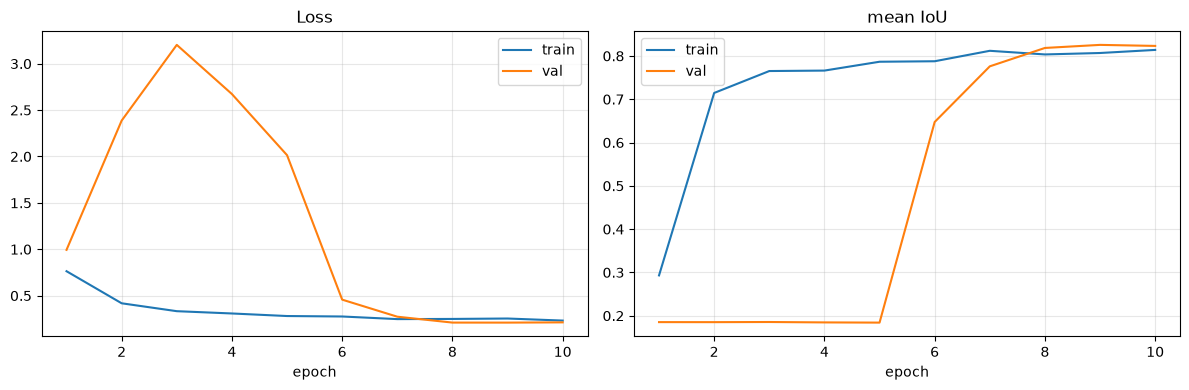

In [10]:
# ============================== TRAINING CURVES ==============================
hist = pd.DataFrame(history) if len(history) else \
       pd.read_csv(os.path.join(CONFIG["results_dir"], "training_history_pointnext.csv"))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist.epoch, hist.tr_loss, label="train"); ax[0].plot(hist.epoch, hist.va_loss, label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist.epoch, hist.tr_miou, label="train"); ax[1].plot(hist.epoch, hist.va_miou, label="val")
ax[1].set_title("mean IoU"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "training_curves_pn2.png"), dpi=150)
plt.show()

## 4. Full-Cloud Inference Utility (400k–800k points)

A full cloud does not fit through PointNeXt in one pass, so the cloud is normalized once,
its points are shuffled and split into 4096-point chunks, all chunks are predicted in
batches, and per-point predictions are scattered back → **every point gets a label**.


In [11]:
# ============================== FULL-CLOUD PREDICTION ==============================
@torch.no_grad()
def predict_full_cloud(model, points_raw, num_points=None, chunk_batch=None, seed=0):
    """
    points_raw: (N,3) original (un-normalized) coordinates.
    Returns per-point predicted labels (N,) covering ALL points.
    """
    num_points = num_points or CONFIG["num_points"]
    chunk_batch = chunk_batch or CONFIG["infer_chunk_batch"]
    model.eval()
    dev = next(model.parameters()).device        # follow the model (GPU or CPU fallback)

    pts_norm, _, _ = normalize_cloud(points_raw)
    N = pts_norm.shape[0]
    rng = np.random.RandomState(seed)
    perm = rng.permutation(N)
    pad = (num_points - N % num_points) % num_points
    if pad:
        perm = np.concatenate([perm, rng.choice(N, pad, replace=True)])
    chunks = perm.reshape(-1, num_points)                        # (n_chunks, num_points)

    pred_full = np.zeros(N, dtype=np.int64)
    i = 0
    while i < len(chunks):
        cidx = chunks[i:i + chunk_batch]                         # (b, num_points)
        try:
            batch = torch.from_numpy(pts_norm[cidx].transpose(0, 2, 1)).to(dev)  # (b,3,P)
            pred = model(batch).argmax(dim=1).cpu().numpy()      # (b, P)
        except torch.cuda.OutOfMemoryError:
            # not enough VRAM for inference -> move to CPU + RAM and redo this batch
            print("[DEVICE] CUDA OOM during inference -> CPU + RAM fallback")
            torch.cuda.empty_cache()
            model.cpu(); dev = torch.device("cpu")
            batch = torch.from_numpy(pts_norm[cidx].transpose(0, 2, 1)).to(dev)
            pred = model(batch).argmax(dim=1).cpu().numpy()
        pred_full[cidx.ravel()] = pred.ravel()                   # padded duplicates just overwrite
        i += chunk_batch
    return pred_full

## 5. Task 1 — Test-Phase Evaluation & Visualization

Runs the **best checkpoint** over every test cloud (full-cloud, all points),
reports Accuracy / per-class IoU / mIoU, and visualizes segmentation results —
**Green = Wood Powder (1), Red = Others (0)**. Colored `.ply` files and `.png`
snapshots are saved to `results/test_vis/`.


In [12]:
# ============================== VISUALIZATION ==============================
# Multi-class palette: 0 = Environment (red), 1 = primary target (green),
# further target classes get distinct fixed colors.
BASE_PALETTE = np.array([
    [0.90, 0.10, 0.10],   # 0 Environment -> red
    [0.00, 0.80, 0.00],   # 1 -> green
    [0.10, 0.30, 0.95],   # 2 -> blue
    [0.95, 0.75, 0.05],   # 3 -> yellow
    [0.75, 0.10, 0.85],   # 4 -> purple
    [0.05, 0.85, 0.85],   # 5 -> cyan
    [0.95, 0.45, 0.05],   # 6 -> orange
    [0.55, 0.35, 0.10],   # 7 -> brown
])
PALETTE_NAMES = ["red", "green", "blue", "yellow", "purple", "cyan", "orange", "brown"]
CLASS_COLORS = {c: BASE_PALETTE[c % len(BASE_PALETTE)]
                for c in range(CONFIG["num_classes"])}

def labels_to_colors(labels):
    colors = np.empty((len(labels), 3), dtype=np.float64)
    for c in range(CONFIG["num_classes"]):
        colors[labels == c] = CLASS_COLORS[c]
    return colors

def legend_string():
    return " | ".join(f"{CONFIG['class_names'].get(c, c)}="
                      f"{PALETTE_NAMES[c % len(PALETTE_NAMES)]}"
                      for c in range(CONFIG["num_classes"]))

CONFIG.setdefault("vis_backend", "open3d")   # "open3d" (interactive window) | "plotly" (in-notebook)

def visualize_segmentation(points, labels, title="Segmentation",
                           save_path=None, show_window=None, max_pts=None):
    """Multi-class 3D visualization. Colors: Environment (0) = red,
    primary target (1) = green, other classes per the fixed palette
    (call legend_string() for the mapping).

    Primary backend: **Open3D interactive window** (rotate/zoom/pan, full resolution).
    NOTE: the Open3D window BLOCKS execution until you close it (press `q` or close
    the window to continue to the next cloud).

    show_window: None = auto (open the Open3D window when vis_backend == "open3d"),
                 True = force window, False = never open a window.

    Always saved (when save_path given):
      - `save_path`.ply  : full-resolution colored cloud (Open3D / CloudCompare / MeshLab)
      - `save_path`.html : interactive 3D fallback (Plotly, if installed)
    Fallback order on headless systems (no display): Plotly inline -> matplotlib 3D (.png).
    """
    max_pts = max_pts or CONFIG["max_vis_points"]
    colors = labels_to_colors(labels)
    backend = CONFIG.get("vis_backend", "open3d")
    window_shown = False

    # ---------- Open3D: full-resolution colored cloud + interactive window ----------
    if HAS_OPEN3D:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(points.astype(np.float64)-np.mean(points.astype(np.float64),axis=0))
        pcd.colors = o3d.utility.Vector3dVector(colors)
        if save_path:
            o3d.io.write_point_cloud(save_path + ".ply", pcd)
        open_now = (show_window is True) or (show_window is None and backend == "open3d")
        if open_now:
            try:
                frame=o3d.geometry.TriangleMesh.create_coordinate_frame(size=1.0,origin=(0,0,0))
                # o3d.visualization.draw_geometries(
                #     [pcd,frame], window_name=title, width=1280, height=800)
                window_shown = True
            except Exception as e:
                print(f"[VIS] Open3D window failed ({e}); no display? "
                      "Falling back to in-notebook 3D.")
    elif backend == "open3d":
        print("[VIS] open3d is not installed -> pip install open3d ; "
              "falling back to in-notebook 3D.")

    if window_shown and backend == "open3d":
        return   # Open3D window already shown at full resolution

    # ---------- In-notebook fallback (subsampled for rendering speed) ----------
    if len(points) > max_pts:
        sel = np.random.choice(len(points), max_pts, replace=False)
        p, lab = points[sel], labels[sel]
    else:
        p, lab = points, labels

    if HAS_PLOTLY:
        c255 = (labels_to_colors(lab) * 255).astype(int)
        col = [f"rgb({r},{g},{b})" for r, g, b in c255]
        fig = go.Figure(data=[go.Scatter3d(
            x=p[:, 0], y=p[:, 1], z=p[:, 2],
            mode="markers",
            marker=dict(size=1.5, color=col, opacity=0.85),
            hoverinfo="skip")])
        fig.update_layout(
            title=title,
            scene=dict(aspectmode="data",
                       xaxis_visible=False, yaxis_visible=False, zaxis_visible=False),
            margin=dict(l=0, r=0, t=40, b=0),
            width=850, height=650, showlegend=False)
        if save_path:
            fig.write_html(save_path + ".html", include_plotlyjs="cdn")
        fig.show()
    else:
        cols = labels_to_colors(lab)
        fig = plt.figure(figsize=(9, 8))
        ax = fig.add_subplot(111, projection="3d")
        ax.scatter(p[:, 0], p[:, 1], p[:, 2], c=cols, s=0.3, linewidths=0)
        ax.set_title(title); ax.set_box_aspect((1, 1, 1)); ax.set_axis_off()
        if save_path:
            plt.savefig(save_path + ".png", dpi=150, bbox_inches="tight")
        plt.show(); plt.close(fig)

# ============================== TEST PHASE ==============================
TEST_VIS_DIR = os.path.join(CONFIG["results_dir"], "test_vis")
os.makedirs(TEST_VIS_DIR, exist_ok=True)

# load best checkpoint
ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded best model (epoch {ckpt['epoch']}, val mIoU {ckpt['val_miou']:.4f})")

conf_test = np.zeros((CONFIG["num_classes"],) * 2, dtype=np.int64)
test_records = []

for i, path in enumerate(tqdm(splits["test"], desc="Testing")):
    pts_raw, lbl_gt = load_pointcloud(path)
    pred = predict_full_cloud(model, pts_raw, seed=CONFIG["seed"])
    conf_test = update_confusion(conf_test, lbl_gt, pred, CONFIG["num_classes"])
    name = os.path.splitext(os.path.basename(path))[0]
    rec = {"file": name, "path": path, "n_points": len(pts_raw)}
    for c in range(1, CONFIG["num_classes"]):      # one count pair per target class
        cname = CONFIG["class_names"].get(c, f"class{c}")
        rec[f"n_{cname}_pred"] = int((pred == c).sum())
        rec[f"n_{cname}_gt"]   = int((lbl_gt == c).sum())
    test_records.append(rec)
    # visualize only the first n_test_visualize test clouds (Task 1 requirement: test phase only)
    if i < CONFIG["n_test_visualize"]:
        visualize_segmentation(pts_raw, pred,
                               title=f"TEST  {name}  (prediction)",
                               save_path=os.path.join(TEST_VIS_DIR, f"{name}_pred"))
        visualize_segmentation(pts_raw, lbl_gt,
                               title=f"TEST  {name}  (ground truth)",
                               save_path=os.path.join(TEST_VIS_DIR, f"{name}_gt"))

acc, ious, miou = seg_metrics(conf_test)

with mlflow.start_run(run_name=f"PointNeXt_Testing_{datetime.datetime.now().strftime('%d_%m_%Y_%H_%M_%S')}"): 
    mlflow.log_metrics({
        "test_Accuracy": acc,
        "test_mIoU": miou,
        **{f"test_IoU_{CONFIG['class_names'].get(c, c)}": float(ious[c])
           for c in range(CONFIG["num_classes"])}
    })
print("\n================ TEST SEGMENTATION RESULTS ================")
print(f"Overall Accuracy : {acc:.4f}")
for c in range(CONFIG["num_classes"]):
    print(f"IoU  {str(CONFIG['class_names'].get(c, c)):<12} ({c}) : {ious[c]:.4f}")
print(f"Mean IoU         : {miou:.4f}")
pd.DataFrame(test_records).to_csv(os.path.join(CONFIG["results_dir"], "test_seg_summary.csv"),
                                  index=False)

Loaded best model (epoch 9, val mIoU 0.8256)


Testing:   0%|          | 0/8 [00:00<?, ?it/s]

🏃 View run PointNeXt_Testing_04_07_2026_07_12_44 at: http://localhost:5000/#/experiments/5/runs/7283934c05514e718135b085da868343
🧪 View experiment at: http://localhost:5000/#/experiments/5

================ TEST SEGMENTATION RESULTS ================
Overall Accuracy : 0.9034
IoU  Environment  (0) : 0.7641
IoU  WoodPowder   (1) : 0.8594
IoU  Object2      (2) : nan
IoU  Object3      (3) : nan
Mean IoU         : 0.8117


## 6. Volume Estimation — Geometric Features → Best Regression Model

**Approach (recommended):**
1. Segment each cloud with the best PointNeXt model → extract predicted **wood-powder points (original coordinates)**.
2. Compute geometric volume features: convex-hull volume/area, bounding-box volume,
   multi-resolution **voxel-occupancy volumes**, point count, height/spread statistics.
3. Fit several regressors (**Linear, Ridge, RandomForest, GradientBoosting**) against the
   GT volume file; the best is chosen by **5-fold cross-validated MAE** on Train+Val
   and finally evaluated on the Test split.

This calibrates raw geometric estimates against ground truth, correcting systematic biases
(hull over-estimation, voxel resolution effects, occlusion, point density).

> ⚠️ Set `CONFIG["voxel_sizes"]` to sensible values for **your coordinate units**.


In [13]:
# ============================== GT VOLUMES ==============================
# NOTE: GT volumes exist ONLY for class CONFIG["gt_class"] (=1). All the
# regressor training and volume error analysis below therefore use class-1
# data only. Other target classes get geometry-based volume (no error calc).
def load_gt_volumes(csv_path):
    """CSV with columns filename,volume. Keys stored without extension."""
    df = pd.read_csv(csv_path)
    cols = {c.lower().strip(): c for c in df.columns}
    fcol = cols.get("filename") or cols.get("file") or df.columns[0]
    vcol = cols.get("volume") or df.columns[1]
    gt = {}
    for _, r in df.iterrows():
        key = os.path.splitext(os.path.basename(str(r[fcol])))[0]
        gt[key] = float(r[vcol])
    print(f"Loaded {len(gt)} GT volumes from {csv_path}")
    return gt

GT_VOLUMES = load_gt_volumes(CONFIG["gt_volume_csv"])

Loaded 63 GT volumes from data/gt_volume.csv


In [14]:
# ============================== VOLUME FEATURES ==============================
FEATURE_NAMES = None  # filled on first call

def compute_volume_features(powder_points, voxel_sizes=None):
    """
    powder_points: (M,3) ORIGINAL-coordinate points predicted as wood powder.
    Returns an ordered feature dict (robust to tiny/empty segments).
    """
    global FEATURE_NAMES
    voxel_sizes = voxel_sizes or CONFIG["voxel_sizes"]
    f = {}
    M = len(powder_points)
    f["n_points"] = float(M)

    if M >= 4:
        mins, maxs = powder_points.min(0), powder_points.max(0)
        ext = np.clip(maxs - mins, 1e-9, None)
        f["bbox_volume"] = float(np.prod(ext))
        f["extent_x"], f["extent_y"], f["extent_z"] = map(float, ext)
        f["z_mean"] = float(powder_points[:, 2].mean() - mins[2])
        f["z_std"]  = float(powder_points[:, 2].std())
        cov = np.cov(powder_points.T)
        f["spread"] = float(np.trace(cov))
        try:
            hull = ConvexHull(powder_points)
            f["hull_volume"], f["hull_area"] = float(hull.volume), float(hull.area)
        except Exception:
            f["hull_volume"] = f["hull_area"] = 0.0
        for vs in voxel_sizes:
            vox = np.unique(np.floor((powder_points - mins) / vs).astype(np.int64), axis=0)
            f[f"voxel_vol_{vs}"] = float(len(vox) * vs ** 3)
        # density proxy
        f["density"] = float(M / max(f["hull_volume"], 1e-9)) if f["hull_volume"] > 0 else 0.0
    else:
        for name in (["bbox_volume", "extent_x", "extent_y", "extent_z", "z_mean", "z_std",
                      "spread", "hull_volume", "hull_area"] +
                     [f"voxel_vol_{vs}" for vs in voxel_sizes] + ["density"]):
            f[name] = 0.0

    if FEATURE_NAMES is None:
        FEATURE_NAMES = list(f.keys())
    return f

def features_to_vector(fdict):
    return np.array([fdict[k] for k in FEATURE_NAMES], dtype=np.float64)

In [15]:
# ============================== BUILD REGRESSION DATASET ==============================
def build_regression_table(file_list, model, gt_volumes, desc="features"):
    """Segment every cloud, extract powder points (original coords), compute features."""
    rows, names = [], []
    for path in tqdm(file_list, desc=desc):
        name = os.path.splitext(os.path.basename(path))[0]
        if name not in gt_volumes:
            continue
        pts_raw, _ = load_pointcloud(path)
        pred = predict_full_cloud(model, pts_raw, seed=CONFIG["seed"])
        powder = pts_raw[pred == CONFIG["gt_class"]]   # GT exists only for this class
        f = compute_volume_features(powder)
        f["gt_volume"] = gt_volumes[name]
        rows.append(f); names.append(name)
    df = pd.DataFrame(rows, index=names)
    return df

# NOTE: with 20,000 clouds this is the slowest step. To develop faster, first run on a
# subset, e.g. splits["train"][:1500]. Feature tables are cached to CSV.
FEA_TRAIN_CSV = os.path.join(CONFIG["results_dir"], "reg_features_trainval_pointnext.csv")
FEA_TEST_CSV  = os.path.join(CONFIG["results_dir"], "reg_features_test_pointnext.csv")

if os.path.exists(FEA_TRAIN_CSV) and os.path.exists(FEA_TEST_CSV):
    df_trainval = pd.read_csv(FEA_TRAIN_CSV, index_col=0)
    df_test     = pd.read_csv(FEA_TEST_CSV, index_col=0)
    FEATURE_NAMES = [c for c in df_trainval.columns if c != "gt_volume"]
    print("Loaded cached feature tables.")
else:
    df_trainval = build_regression_table(splits["train"] + splits["val"], model,
                                         GT_VOLUMES, desc="Train+Val features")
    df_test     = build_regression_table(splits["test"], model,
                                         GT_VOLUMES, desc="Test features")
    df_trainval.to_csv(FEA_TRAIN_CSV); df_test.to_csv(FEA_TEST_CSV)

print("Train+Val:", df_trainval.shape, "| Test:", df_test.shape)
df_trainval.head()

Train+Val features:   0%|          | 0/37 [00:00<?, ?it/s]

Test features:   0%|          | 0/8 [00:00<?, ?it/s]

Train+Val: (37, 15) | Test: (8, 15)


,n_points,bbox_volume,extent_x,extent_y,extent_z,z_mean,z_std,spread,hull_volume,hull_area,voxel_vol_0.01,voxel_vol_0.02,voxel_vol_0.05,density,gt_volume
sample_data_0045,295826.0,229.453285,7.2141,6.0048,5.2968,2.390932,1.262690,5.857077,45.103909,94.541988,0.223892,0.992640,3.147250,6558.766295,61.0
sample_data_0032,256152.0,172.528436,6.2123,6.0905,4.5599,2.353830,1.230648,5.101991,34.690035,80.857753,0.194585,0.858864,2.796750,7384.022534,53.0
sample_data_0033,277413.0,194.475532,6.3945,5.5238,5.5058,2.351886,1.259504,4.973663,41.968965,88.597053,0.208246,0.923224,2.919000,6609.955690,53.0
sample_data_008,348984.0,392.389307,9.0036,9.8026,4.4459,2.223560,1.220359,10.459545,77.017752,153.897956,0.279198,1.501240,5.213625,4531.215092,86.0
sample_data_0041,268001.0,217.869556,7.0529,6.7968,4.5449,2.281831,1.249310,5.367078,30.052062,82.329830,0.206401,0.915072,2.974750,8917.890467,56.0


In [16]:
# ============================== MODEL SELECTION (BEST REGRESSOR) ==============================
X_tv = df_trainval[FEATURE_NAMES].values
y_tv = df_trainval["gt_volume"].values
X_te = df_test[FEATURE_NAMES].values
y_te = df_test["gt_volume"].values

scaler = StandardScaler().fit(X_tv)
X_tv_s, X_te_s = scaler.transform(X_tv), scaler.transform(X_te)

candidates = {
    "Linear":            (LinearRegression(), True),
    "Ridge":             (Ridge(alpha=1.0), True),
    "RandomForest":      (RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                                                n_jobs=-1, random_state=CONFIG["seed"]), False),
    "GradientBoosting":  (GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                    max_depth=3, subsample=0.9,
                                                    random_state=CONFIG["seed"]), False),
}

kf = KFold(n_splits=5, shuffle=True, random_state=CONFIG["seed"])
cv_results = {}
for name, (est, use_scaled) in candidates.items():
    X = X_tv_s if use_scaled else X_tv
    mae = -cross_val_score(est, X, y_tv, cv=kf,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
    cv_results[name] = mae.mean()
    print(f"{name:18s}  CV MAE = {mae.mean():.6f}  (+/- {mae.std():.6f})")

best_name = min(cv_results, key=cv_results.get)
best_est, best_scaled = candidates[best_name]
print(f"\n>>> Best regression model: {best_name}")

best_est.fit(X_tv_s if best_scaled else X_tv, y_tv)
joblib.dump({"model": best_est, "scaler": scaler, "use_scaled": best_scaled,
             "feature_names": FEATURE_NAMES, "name": best_name},
            os.path.join(CONFIG["checkpoint_dir"], "best_volume_regressor_pointnext.joblib"))
print("Saved -> checkpoints/best_volume_regressor_pointnext.joblib")

Linear              CV MAE = 19.950673  (+/- 12.303214)
Ridge               CV MAE = 10.583656  (+/- 4.506845)
RandomForest        CV MAE = 10.051069  (+/- 4.076325)
GradientBoosting    CV MAE = 10.192370  (+/- 3.691859)

>>> Best regression model: RandomForest
Saved -> checkpoints/best_volume_regressor_pointnext.joblib


### 6.1 Volume Error Analysis on the Test Split (vs GT)

🏃 View run PointNeXt_Volume_Error_04_07_2026_07_14_25 at: http://localhost:5000/#/experiments/5/runs/0fc9d12ead7a46e3a2db19ef7158b3ea
🧪 View experiment at: http://localhost:5000/#/experiments/5
[Regression:RandomForest (class 1 only)]  MAE=7.614440  RMSE=9.238179  MAPE=10.63%  R2=0.6190
🏃 View run PointNeXt_Volume_Error_04_07_2026_07_14_25 at: http://localhost:5000/#/experiments/5/runs/31e69a74310145449b84c5edc7aaff32
🧪 View experiment at: http://localhost:5000/#/experiments/5
[Baseline:RawConvexHull]  MAE=22.643593  RMSE=24.744026  MAPE=32.18%  R2=-1.7333


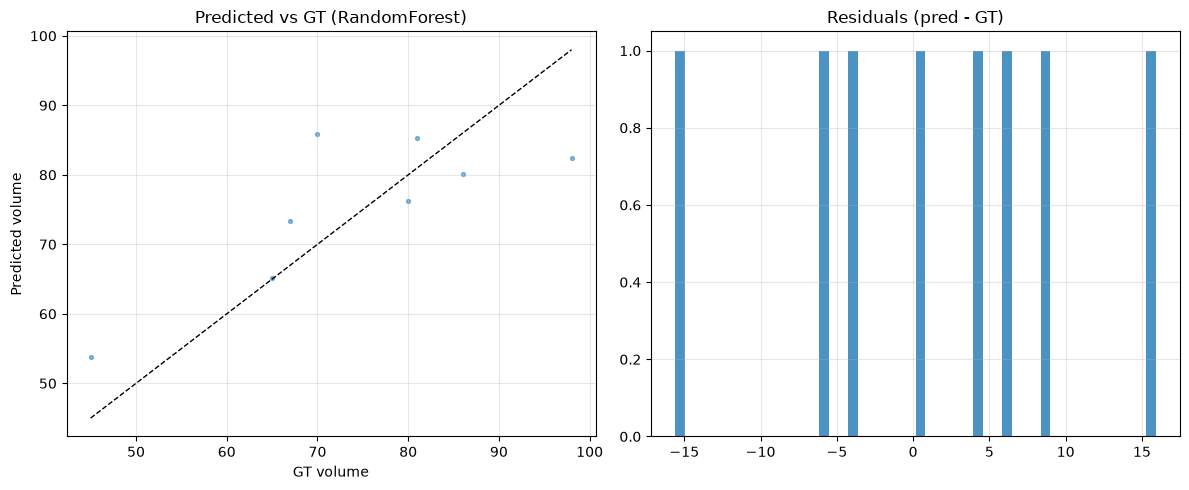

In [17]:
# # ============================== ERROR ANALYSIS ==============================
# def volume_error_report(y_true, y_pred, label=""):
#     mae  = mean_absolute_error(y_true, y_pred)
#     rmse = math.sqrt(mean_squared_error(y_true, y_pred))
#     mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100
#     r2   = r2_score(y_true, y_pred)
#     print(f"[{label}]  MAE={mae:.6f}  RMSE={rmse:.6f}  MAPE={mape:.2f}%  R2={r2:.4f}")
#     return dict(model=label, MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)

# ============================== ERROR ANALYSIS ==============================
def volume_error_report(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100
    r2   = r2_score(y_true, y_pred)
    
    # ---> MLFLOW ERROR LOGGING <---
    with mlflow.start_run(run_name=f"PointNeXt_Volume_Error_{datetime.datetime.now().strftime('%d_%m_%Y_%H_%M_%S')}"):
        mlflow.log_metrics({
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
            "R2": r2
        })
    # ------------------------------
    
    print(f"[{label}]  MAE={mae:.6f}  RMSE={rmse:.6f}  MAPE={mape:.2f}%  R2={r2:.4f}")
    return dict(model=label, MAE=mae, RMSE=rmse, MAPE=mape, R2=r2)

y_pred_te = best_est.predict(X_te_s if best_scaled else X_te)
reports = [volume_error_report(y_te, y_pred_te, f"Regression:{best_name} (class {CONFIG['gt_class']} only)")]

# baseline: raw convex-hull volume with no learning (for comparison)
hull_col = FEATURE_NAMES.index("hull_volume")
reports.append(volume_error_report(y_te, X_te[:, hull_col], "Baseline:RawConvexHull"))

pd.DataFrame(reports).to_csv(os.path.join(CONFIG["results_dir"], "volume_error_report.csv"),
                             index=False)

# scatter + residual plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(y_te, y_pred_te, s=8, alpha=0.5)
lim = [min(y_te.min(), y_pred_te.min()), max(y_te.max(), y_pred_te.max())]
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set_xlabel("GT volume"); ax[0].set_ylabel("Predicted volume")
ax[0].set_title(f"Predicted vs GT ({best_name})"); ax[0].grid(alpha=.3)
res = y_pred_te - y_te
ax[1].hist(res, bins=50, alpha=0.8)
ax[1].set_title("Residuals (pred - GT)"); ax[1].grid(alpha=.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "volume_error_analysis.png"), dpi=150)
plt.show()

pd.DataFrame({"file": df_test.index, "gt": y_te, "pred": y_pred_te,
              "abs_err": np.abs(res), "rel_err_%": np.abs(res)/np.clip(y_te,1e-9,None)*100}
             ).to_csv(os.path.join(CONFIG["results_dir"], "volume_test_predictions.csv"),
                      index=False)

## 7. (Optional Alternative) PointNeXt → Direct Volume Regression

End-to-end alternative: the PointNeXt encoder's global 512-d embedding (deepest SA level, max-pooled) + an MLP head regresses the
volume directly from a sampled chunk of the cloud. Useful for comparison; in practice the
geometric-feature regressor above is usually more accurate and far cheaper to train, because
a single 4096-point sample can't fully observe a 400k–800k-point cloud.
Set `RUN_DGCNN_REGRESSION = True` to train it.


In [21]:
RUN_POINTNEXT_REGRESSION = True   # set True to train the PointNeXt regression variant

class PointNeXt_Reg(nn.Module):
    """Frozen (or finetuned) PointNeXt encoder -> global embedding -> MLP -> volume."""
    def __init__(self, seg_backbone: PointNeXt_Seg, emb_dims=None, finetune=False):
        super().__init__()
        # default derived from the backbone (512 PointNeXt / 256 PTv1 / 384 PTv2)
        emb_dims = emb_dims or seg_backbone.emb_dims
        self.backbone = seg_backbone
        for p in self.backbone.parameters():
            p.requires_grad = finetune
        self.head = nn.Sequential(
            nn.Linear(emb_dims, 512), nn.BatchNorm1d(512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        emb = self.backbone(x, return_embedding=True)   # (B, emb)
        return self.head(emb).squeeze(-1)               # (B,)

class VolumeDataset(Dataset):
    """Random 4096-point chunk of the whole cloud -> GT volume (log1p target)."""
    def __init__(self, files, gt_volumes, num_points):
        self.items = [(f, gt_volumes[os.path.splitext(os.path.basename(f))[0]])
                      for f in files
                      if os.path.splitext(os.path.basename(f))[0] in gt_volumes]
        self.num_points = num_points
    def __len__(self): return len(self.items)
    def __getitem__(self, idx):
        path, vol = self.items[idx]
        pts, lbl = load_pointcloud(path)
        if lbl is not None and int((lbl == CONFIG["gt_class"]).sum()) >= 64:
            pts = pts[lbl == CONFIG["gt_class"]]   # GT volume belongs to this class only
        pts, _, _ = normalize_cloud(pts)
        choice = np.random.choice(len(pts), self.num_points, replace=len(pts) < self.num_points)
        return (torch.from_numpy(pts[choice].T.copy()),
                torch.tensor(np.log1p(vol), dtype=torch.float32))

if RUN_POINTNEXT_REGRESSION:
    reg_backbone = PointNeXt_Seg(num_classes=CONFIG["num_classes"],
                                 dropout=CONFIG["dropout"]).to(DEVICE)
    reg_backbone.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)["model_state"])
    reg_model = PointNeXt_Reg(reg_backbone, emb_dims=reg_backbone.emb_dims, finetune=False).to(DEVICE)

    tr = DataLoader(VolumeDataset(splits["train"], GT_VOLUMES, CONFIG["num_points"]),
                    batch_size=CONFIG["batch_size"], shuffle=True,
                    num_workers=CONFIG["num_workers"], drop_last=True)
    va = DataLoader(VolumeDataset(splits["val"], GT_VOLUMES, CONFIG["num_points"]),
                    batch_size=CONFIG["batch_size"], shuffle=False,
                    num_workers=CONFIG["num_workers"])
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, reg_model.parameters()), lr=1e-3)
    lossf = nn.SmoothL1Loss()
    best_val = float("inf")
    REG_CKPT = os.path.join(CONFIG["checkpoint_dir"], "best_pointnext_reg.pth")

    for ep in range(1, 51):
        reg_model.train(); tl = 0.0
        for pts, vol in tqdm(tr, leave=False, desc=f"reg-train ep{ep}"):
            pts, vol = pts.to(DEVICE), vol.to(DEVICE)
            loss = lossf(reg_model(pts), vol)
            opt.zero_grad(); loss.backward(); opt.step()
            tl += loss.item() * pts.size(0)
        reg_model.eval(); vp, vg = [], []
        with torch.no_grad():
            for pts, vol in va:
                vp.append(reg_model(pts.to(DEVICE)).cpu().numpy()); vg.append(vol.numpy())
        vmae = mean_absolute_error(np.expm1(np.concatenate(vg)),
                                   np.expm1(np.concatenate(vp)))
        star = ""
        if vmae < best_val:
            best_val = vmae
            torch.save({"model_state": reg_model.state_dict()}, REG_CKPT); star = " <-- best"
        print(f"[PointNeXt-Reg] ep {ep:02d} train_loss {tl/len(tr.dataset):.4f} "
              f"val MAE {vmae:.6f}{star}")

    # test evaluation
    reg_model.load_state_dict(torch.load(REG_CKPT, map_location=DEVICE, weights_only=False)["model_state"])
    reg_model.eval(); tp, tg, names = [], [], []
    te = VolumeDataset(splits["test"], GT_VOLUMES, CONFIG["num_points"])
    with torch.no_grad():
        for pts, vol in DataLoader(te, batch_size=CONFIG["batch_size"]):
            tp.append(reg_model(pts.to(DEVICE)).cpu().numpy()); tg.append(vol.numpy())
    volume_error_report(np.expm1(np.concatenate(tg)), np.expm1(np.concatenate(tp)),
                        "PointNeXt-Regression")
else:
    print("PointNeXt regression skipped (RUN_POINTNEXT_REGRESSION = False).")

reg-train ep1:   0%|          | 0/3 [00:00<?, ?it/s]

[PointNeXt-Reg] ep 01 train_loss 2.7322 val MAE 66.448936 <-- best


reg-train ep2:   0%|          | 0/3 [00:00<?, ?it/s]

[PointNeXt-Reg] ep 02 train_loss 2.6086 val MAE 66.382408 <-- best


reg-train ep3:   0%|          | 0/3 [00:00<?, ?it/s]

...

[PointNeXt-Reg] ep 48 train_loss 0.0646 val MAE 26.299217


reg-train ep49:   0%|          | 0/3 [00:00<?, ?it/s]

[PointNeXt-Reg] ep 49 train_loss 0.0364 val MAE 25.534666


reg-train ep50:   0%|          | 0/3 [00:00<?, ?it/s]

[PointNeXt-Reg] ep 50 train_loss 0.0490 val MAE 26.881561
🏃 View run PointNeXt_Volume_Error_04_07_2026_07_18_21 at: http://localhost:5000/#/experiments/5/runs/1e431861782046afa70456c5584e5b16
🧪 View experiment at: http://localhost:5000/#/experiments/5
[PointNeXt-Regression]  MAE=30.584059  RMSE=32.972911  MAPE=41.39%  R2=-3.8536


## 8. Task 2 — Standalone Inference Pipeline

`WoodPowderInferencePipeline`:
- loads the **best saved segmentation model** and the **best saved volume regressor**,
- runs on **one or many** point cloud files (labels not required),
- **visualizes** segmentation (Green = Wood Powder, Red = Others; saves `.ply` + `.png`),
- returns the **estimated wood-powder volume** per file (+ error vs GT if available).

This cell is self-contained relative to the utility functions defined above; to deploy it as a
separate script, copy Sections 0–2 (imports, `CONFIG`, I/O utilities, `DGCNN_Seg`,
`predict_full_cloud`, `compute_volume_features`, `visualize_segmentation`) together with it.


In [22]:
# ============================== INFERENCE PIPELINE (TASK 2, MULTI-CLASS) ==============================
class MultiObjectInferencePipeline:
    """GT-free inference: segment ALL target classes and estimate a volume per class.

    Volume policy (GT exists only for class CONFIG["gt_class"]):
      - class == gt_class          -> trained ML regressor (calibrated on class-1 GT)
      - other target classes       -> geometry (convex hull) volume by default;
                                      if CONFIG["apply_regressor_to_all_classes"] is True,
                                      the class-1 regressor is also applied and the row is
                                      flagged calibrated=False (no GT to validate it).
    """

    def __init__(self,
                 seg_checkpoint=os.path.join(CONFIG["checkpoint_dir"], "best_pointnext_seg.pth"),
                 regressor_path=os.path.join(CONFIG["checkpoint_dir"],
                                             "best_volume_regressor_pointnext.joblib"),
                 device=None):
        self.device = device or select_device(CONFIG)   # CUDA only with enough free VRAM
        ckpt = torch.load(seg_checkpoint, map_location=self.device, weights_only=False)
        cfg = ckpt.get("config", CONFIG)
        self.model = PointNeXt_Seg(num_classes=cfg["num_classes"],
                              dropout=cfg.get("dropout", 0.5)).to(self.device)
        self.model.load_state_dict(ckpt["model_state"])
        self.model.eval()
        print(f"[Pipeline] Segmentation model loaded "
              f"(epoch {ckpt.get('epoch','?')}, val mIoU {ckpt.get('val_miou', float('nan')):.4f})")
        self.reg = joblib.load(regressor_path) if os.path.exists(regressor_path) else None
        print("[Pipeline] ML volume regressor:",
              self.reg["name"] if self.reg else "not found -> convex-hull volume for all classes")

    # ---------- volume for ONE class segment ----------
    def _class_volume(self, pts_c, cls):
        feats = compute_volume_features(pts_c)
        use_reg = self.reg is not None and (
            cls == CONFIG["gt_class"] or CONFIG["apply_regressor_to_all_classes"])
        if use_reg and len(pts_c) >= 4:
            x = features_to_vector(feats).reshape(1, -1)
            if self.reg["use_scaled"]:
                x = self.reg["scaler"].transform(x)
            vol = max(float(self.reg["model"].predict(x)[0]), 0.0)
            method = f"ML:{self.reg['name']}"
        else:
            vol, method = feats["hull_volume"], "geometry:convex_hull"
        calibrated = (cls == CONFIG["gt_class"]) and use_reg
        return vol, method, calibrated, feats

    # ---------- one cloud ----------
    def infer_one(self, path, visualize=True, show_window=None, save_dir=None):
        name = os.path.splitext(os.path.basename(path))[0]
        pts_raw, _ = load_pointcloud(path)            # GT labels IGNORED in inference
        pred = predict_full_cloud(self.model, pts_raw)

        rows = []
        for cls in range(1, CONFIG["num_classes"]):   # every TARGET class
            cname = CONFIG["class_names"].get(cls, f"class{cls}")
            pts_c = pts_raw[pred == cls]
            if len(pts_c) == 0:
                rows.append({"file": name, "class_id": cls, "class_name": cname,
                             "detected": False, "n_class_points": 0,
                             "estimated_volume": 0.0, "volume_method": "none",
                             "calibrated": False})
                continue
            vol, method, calibrated, _ = self._class_volume(pts_c, cls)
            rows.append({"file": name, "class_id": cls, "class_name": cname,
                         "detected": True, "n_class_points": int(len(pts_c)),
                         "class_ratio": float(len(pts_c) / len(pts_raw)),
                         "estimated_volume": vol, "volume_method": method,
                         "calibrated": calibrated})
            # GT check only for the calibrated class
            if cls == CONFIG["gt_class"] and name in GT_VOLUMES:
                gt = GT_VOLUMES[name]
                rows[-1].update(gt_volume=gt, abs_error=abs(vol - gt),
                                rel_error_pct=abs(vol - gt) / max(abs(gt), 1e-9) * 100)

        if visualize:
            sp = None
            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
                sp = os.path.join(save_dir, f"{name}_inference")
            det = ", ".join(f"{r['class_name']}={r['estimated_volume']:.3f}"
                            for r in rows if r["detected"])
            visualize_segmentation(pts_raw, pred,
                                   title=f"{name} | {det} | {legend_string()}",
                                   save_path=sp, show_window=show_window)
        return rows, pred

    # ---------- one or many clouds ----------
    def run(self, paths, visualize=True, show_window=None,
            save_dir=os.path.join(CONFIG["results_dir"], "inference")):
        if isinstance(paths, str):
            paths = [paths]
        all_rows = []
        for p in paths:
            rows, _ = self.infer_one(p, visualize=visualize,
                                     show_window=show_window, save_dir=save_dir)
            for r in rows:
                if r["detected"]:
                    tagtxt = "" if r["calibrated"] else "  [uncalibrated]" \
                             if r["volume_method"].startswith("ML") else ""
                    print(f"  -> {r['file']} | {r['class_name']:<12} "
                          f"points={r['n_class_points']:,} "
                          f"volume={r['estimated_volume']:.6f} "
                          f"({r['volume_method']}){tagtxt}"
                          + (f" | GT={r['gt_volume']:.6f} "
                             f"(rel err {r['rel_error_pct']:.2f}%)"
                             if "gt_volume" in r else ""))
            all_rows += rows
        df = pd.DataFrame(all_rows)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            df.to_csv(os.path.join(save_dir, "inference_results.csv"), index=False)
        return df

In [23]:
# ============================== RUN INFERENCE (EXAMPLES) ==============================
pipeline = MultiObjectInferencePipeline()

# --- Example 1: a single point cloud ---
# result_df = pipeline.run("./data/pointclouds/sample_0001.npy")

# --- Example 2: multiple specific files ---
# result_df = pipeline.run(["./data/pointclouds/a.las", "./data/pointclouds/b.las"])

# --- Example 3: a few clouds from the test split (works out of the box) ---
# One row PER (file, target class): per-class point count + per-class estimated volume.
result_df = pipeline.run(splits["test"][:3], visualize=True)  # Open3D window per cloud; close (q) to continue
result_df

[DEVICE] Using CUDA: NVIDIA GeForce RTX 3060 | free VRAM 7.80/11.63 GB
[Pipeline] Segmentation model loaded (epoch 9, val mIoU 0.8256)
[Pipeline] ML volume regressor: RandomForest
  -> sample_data_003 | WoodPowder   points=348,068 volume=84.801187 (ML:RandomForest) | GT=81.000000 (rel err 4.69%)
  -> sample_data_0026 | WoodPowder   points=295,419 volume=73.649500 (ML:RandomForest) | GT=67.000000 (rel err 9.92%)
  -> sample_data_009 | WoodPowder   points=442,465 volume=80.092857 (ML:RandomForest) | GT=86.000000 (rel err 6.87%)


,file,class_id,class_name,detected,n_class_points,class_ratio,estimated_volume,volume_method,calibrated,gt_volume,abs_error,rel_error_pct
0,sample_data_003,1,WoodPowder,True,348068,0.539516,84.801187,ML:RandomForest,True,81.0,3.801187,4.692823
1,sample_data_003,2,Object2,False,0,NaN,0.000000,none,False,NaN,NaN,NaN
2,sample_data_003,3,Object3,False,0,NaN,0.000000,none,False,NaN,NaN,NaN
3,sample_data_0026,1,WoodPowder,True,295419,0.602770,73.649500,ML:RandomForest,True,67.0,6.649500,9.924627
4,sample_data_0026,2,Object2,False,0,NaN,0.000000,none,False,NaN,NaN,NaN
5,sample_data_0026,3,Object3,False,0,NaN,0.000000,none,False,NaN,NaN,NaN
6,sample_data_009,1,WoodPowder,True,442465,0.682597,80.092857,ML:RandomForest,True,86.0,5.907143,6.868771
7,sample_data_009,2,Object2,False,0,NaN,0.000000,none,False,NaN,NaN,NaN
8,sample_data_009,3,Object3,False,0,NaN,0.000000,none,False,NaN,NaN,NaN


---
### Notes & Tuning Tips
- **Speed**: with 20,000 clouds × 400–800k points, full training is heavy. Start with a subset
  (e.g. slice `splits["train"]`), verify the pipeline end-to-end, then scale up. Increase
  `chunks_per_cloud_train` for better cloud coverage per epoch.
- **Units**: `voxel_sizes` and all volumes are in your data's coordinate units — verify the GT
  volume file uses the same unit system (e.g. m³ vs cm³) before interpreting errors.
- **Class imbalance**: weighted CrossEntropy is enabled; if powder IoU stays low, try focal loss
  or oversampling powder-rich chunks.
- **Interactive 3D**: set `show_window=True` in the pipeline (requires a display + open3d);
  on headless servers use the saved `.ply` files (open in CloudCompare/MeshLab) or `.png` snapshots.

**Multi-class additions in this notebook**
- Labels are `0..K` (0 = environment, `1..K` = target objects) — set
  `CONFIG["num_classes"]` (= 1 + K) and `CONFIG["class_names"]` to match your data.
- GT volumes exist **only for class 1** (`CONFIG["gt_class"]`): the ML/DL regressors
  train on class-1 data and the error analysis (MAE/RMSE/MAPE/R2) covers class 1 only.
- Other detected classes get **geometry (convex-hull) volume**; set
  `CONFIG["apply_regressor_to_all_classes"] = True` to also apply the class-1
  regressor to them (rows are flagged `calibrated=False`).
- Inference output = one row per (file, target class): point count + volume + method.
- Checkpoints: `best_pointnext_seg.pth`, `best_volume_regressor_pointnext.joblib`,
  `best_pointnext_reg.pth` (optional DL variant).
